# Volatility-Adjusted Momentum — 6M — Winner Drift

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('vol_adjusted', '6M', 'winner_drift')

## 1. Signal and portfolio rule

Score = formation-period price return / annualized sample standard deviation of daily log returns. Annualization uses √252. The signal rewards stronger returns per unit of realized variability; it does not set inverse-volatility portfolio weights.

Continuing holdings retain their naturally drifted weights, capped at 2/N at scheduled rebalances. Exits and entrants are paired in stable symbol order; an entrant receives min(exit weight, 1/N). Excess exit weight and cap trims are spread equally among continuing holdings with room below the cap. Unmatched entrants share existing cash up to 1/N each. Residual cash is retained. The cap is a scheduled target constraint, not a daily trim rule.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,3.563,"2,261,224,535.95"
NSE:YASHO-EQ,3.430,"37,220,195.50"
NSE:UFBL-EQ,3.330,"42,078,240.59"
NSE:HFCL-EQ,3.264,"3,688,024,397.99"
NSE:CPPLUS-EQ,3.199,"588,775,647.85"
NSE:WELCORP-EQ,3.186,"698,746,108.38"
NSE:DIACABS-EQ,2.993,"490,913,783.79"
NSE:RPTECH-EQ,2.761,"78,147,051.55"
NSE:LAURUSLABS-EQ,2.736,"2,123,882,567.10"
NSE:SHADOWFAX-EQ,2.634,"320,801,875.19"


Symbol,Leg,Actual weight,Current selection,Execution status,Return / volatility,MDTV (INR)
NSE:CUPID-EQ,long,0.7%,True,selected,3.563,"2,261,224,535.95"
NSE:YASHO-EQ,long,0.7%,True,selected,3.430,"37,220,195.50"
NSE:UFBL-EQ,long,0.4%,True,selected,3.330,"42,078,240.59"
NSE:HFCL-EQ,long,0.8%,True,selected,3.264,"3,688,024,397.99"
NSE:CPPLUS-EQ,long,0.7%,True,selected,3.199,"588,775,647.85"
NSE:WELCORP-EQ,long,0.5%,True,selected,3.186,"698,746,108.38"
NSE:DIACABS-EQ,long,0.4%,True,selected,2.993,"490,913,783.79"
NSE:RPTECH-EQ,long,0.7%,True,selected,2.761,"78,147,051.55"
NSE:LAURUSLABS-EQ,long,0.6%,True,selected,2.736,"2,123,882,567.10"
NSE:SHADOWFAX-EQ,long,0.2%,True,selected,2.634,"320,801,875.19"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:CUPID-EQ,2026-01-30,80.20,2026-07-31,230.62,187.6%


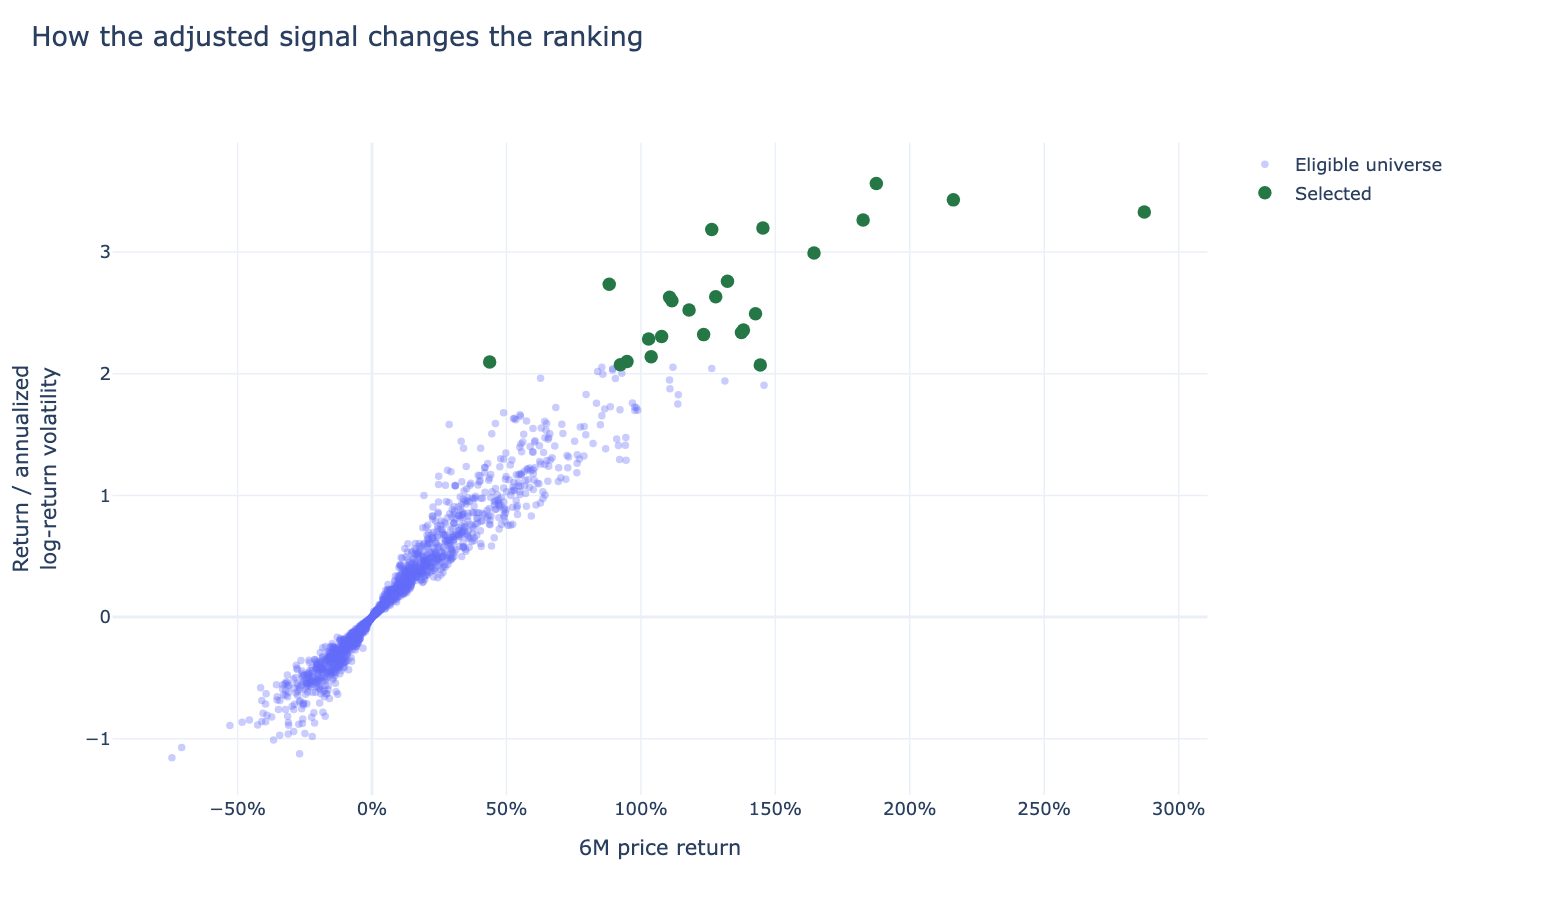

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,10.3%,9.9%,9.0%
1M,24,13.1%,12.5%,11.2%
1M,50,15.7%,15.0%,13.3%
3M,12,20.6%,20.1%,17.7%
3M,24,12.5%,12.1%,10.6%
3M,50,12.4%,12.0%,10.7%
6M,12,11.8%,11.6%,10.3%
6M,24,9.7%,9.5%,8.4%
6M,50,10.8%,10.6%,9.5%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,9.0%,0.194,-62.0%,6.1%
1M,24,11.2%,0.341,-70.5%,5.9%
1M,50,13.3%,0.468,-69.5%,6.0%
3M,12,17.7%,0.586,-61.7%,8.0%
3M,24,10.6%,0.280,-70.1%,7.3%
3M,50,10.7%,0.297,-70.4%,7.0%
6M,12,10.3%,0.270,-63.1%,6.6%
6M,24,8.4%,0.154,-66.8%,6.3%
6M,50,9.5%,0.231,-66.1%,6.0%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,10.8%,92.0%,1720
1M,24,12.1%,91.1%,1587
1M,50,11.8%,89.4%,1581
3M,12,14.2%,93.9%,1565
3M,24,13.5%,92.8%,1731
3M,50,12.5%,91.5%,1647
6M,12,11.6%,93.7%,1593
6M,24,13.1%,93.8%,1918
6M,50,11.8%,91.5%,1653


### CAGR

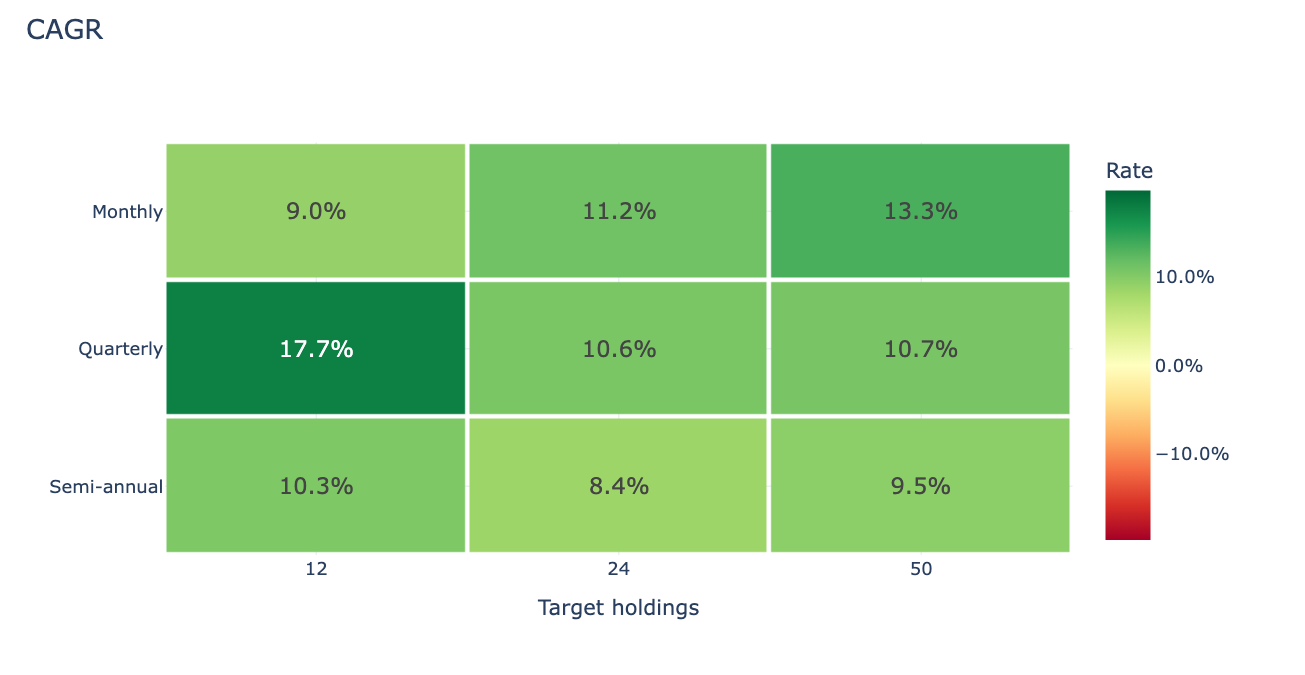

In [5]:
research.heatmap('cagr')

### Sharpe ratio

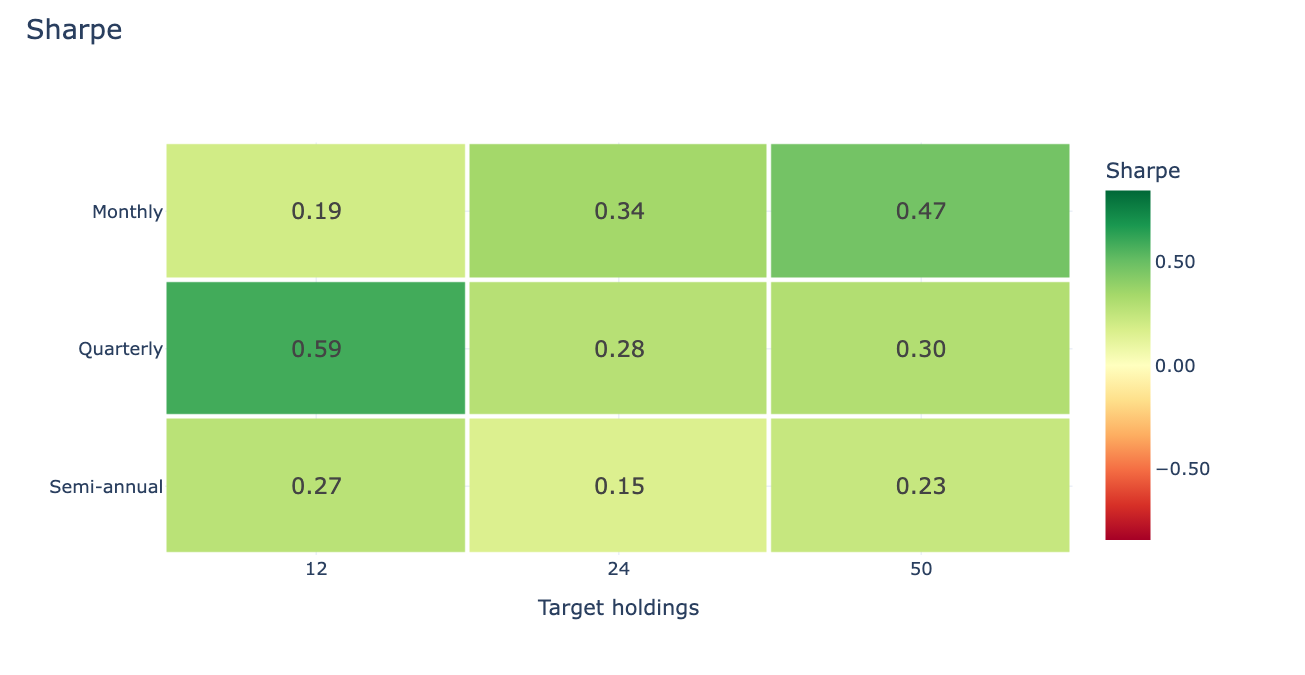

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

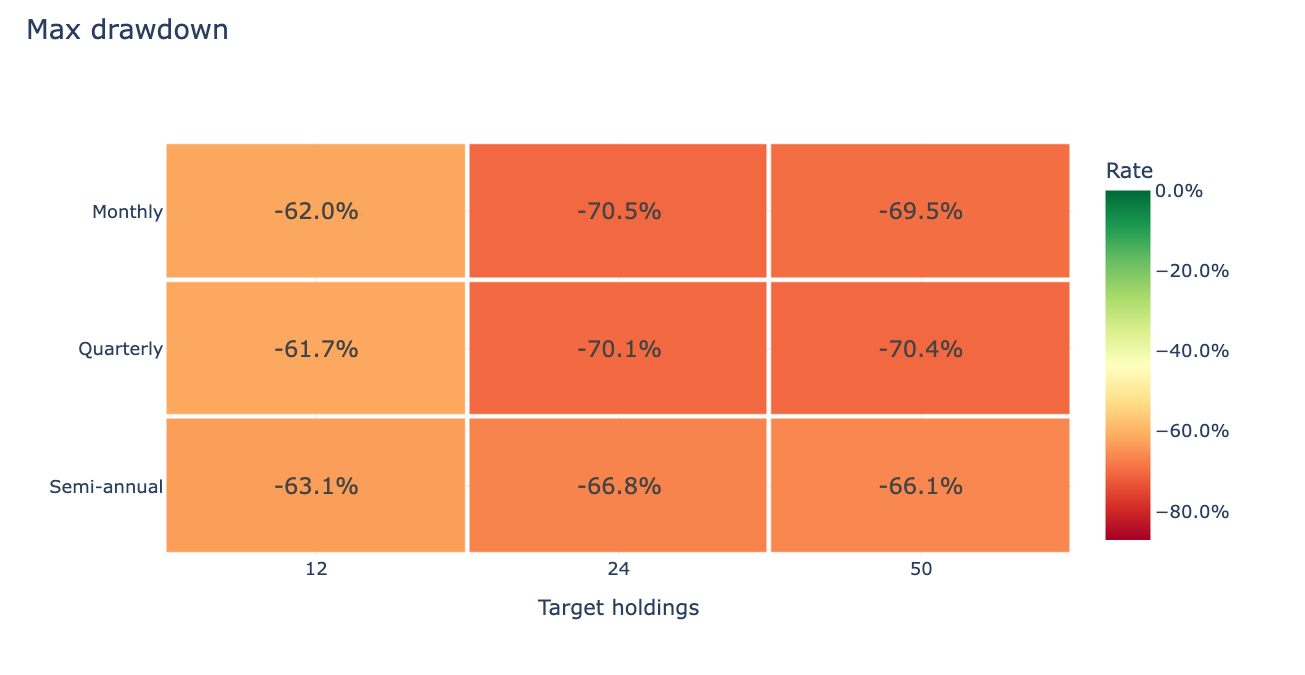

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

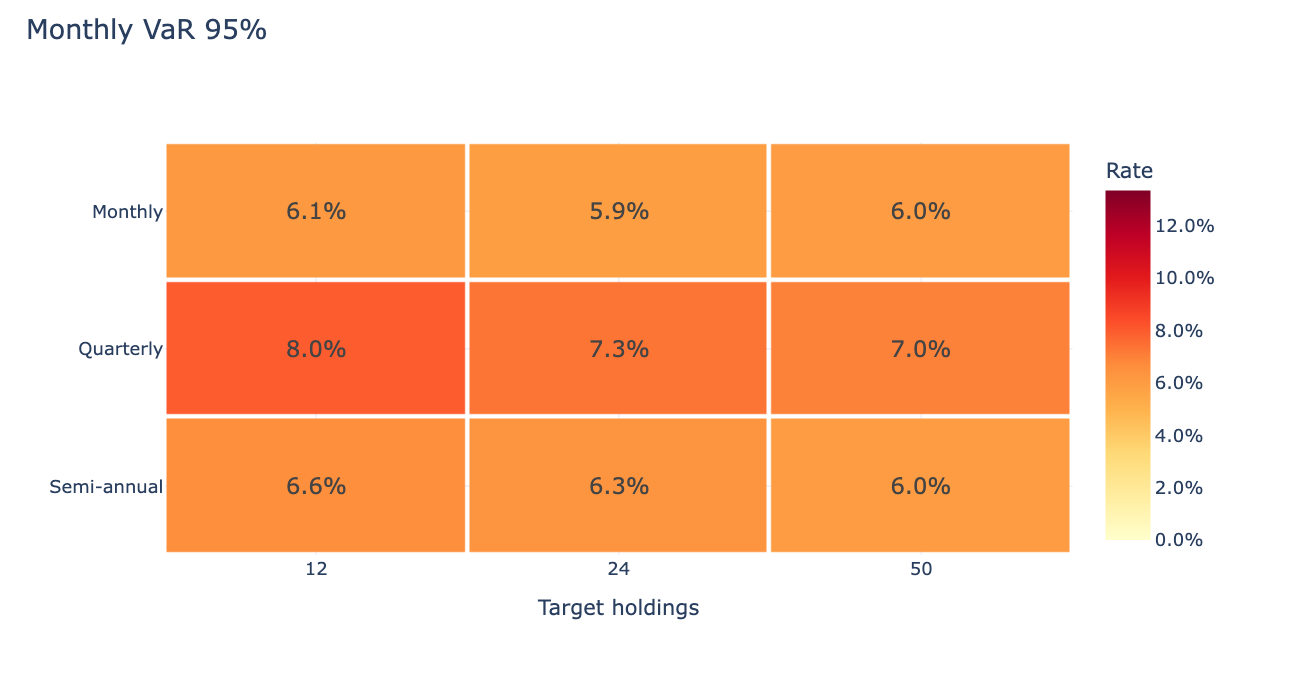

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

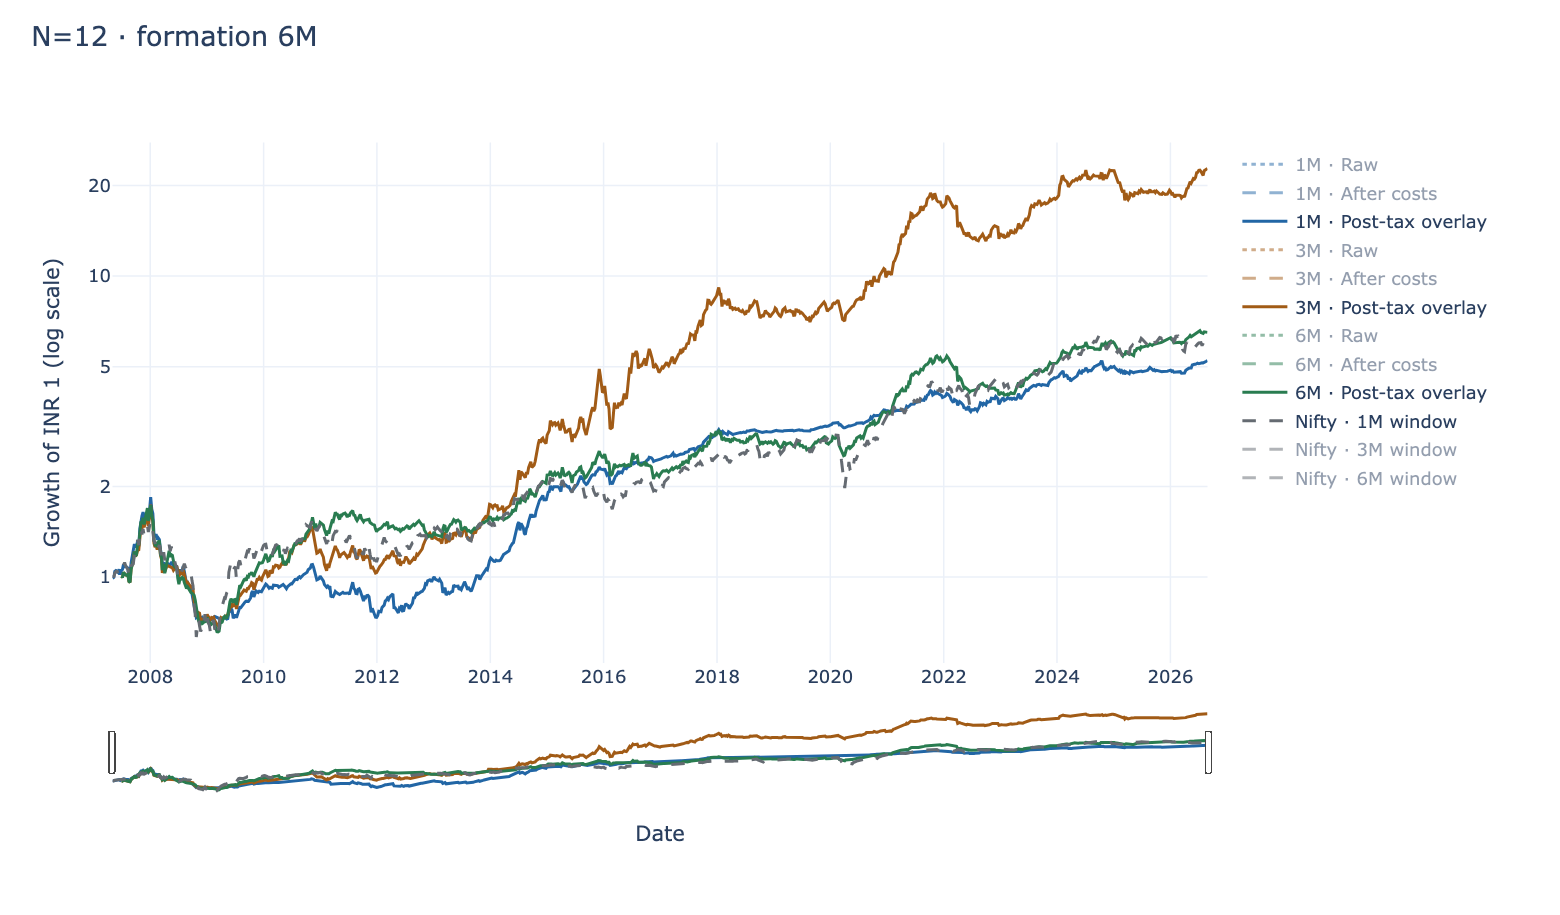

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,10.3%,0.296,-60.1%,5.8%
1M,After costs,9.9%,0.265,-60.5%,6.1%
1M,Post-tax overlay,9.0%,0.194,-62.0%,6.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,20.6%,0.724,-59.5%,7.8%
3M,After costs,20.1%,0.696,-59.7%,8.0%
3M,Post-tax overlay,17.7%,0.586,-61.7%,8.0%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,11.8%,0.367,-60.0%,6.5%
6M,After costs,11.6%,0.353,-60.3%,6.6%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,10.2%,89.9%,1679
1M,After costs,10.5%,90.6%,1687
3M,Raw,13.2%,92.6%,1467
3M,After costs,13.3%,92.8%,1469
6M,Raw,10.7%,92.5%,797
6M,After costs,10.8%,92.7%,798
1M,Post-tax overlay,10.8%,92.0%,1720
3M,Post-tax overlay,14.2%,93.9%,1565
6M,Post-tax overlay,11.6%,93.7%,1593
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

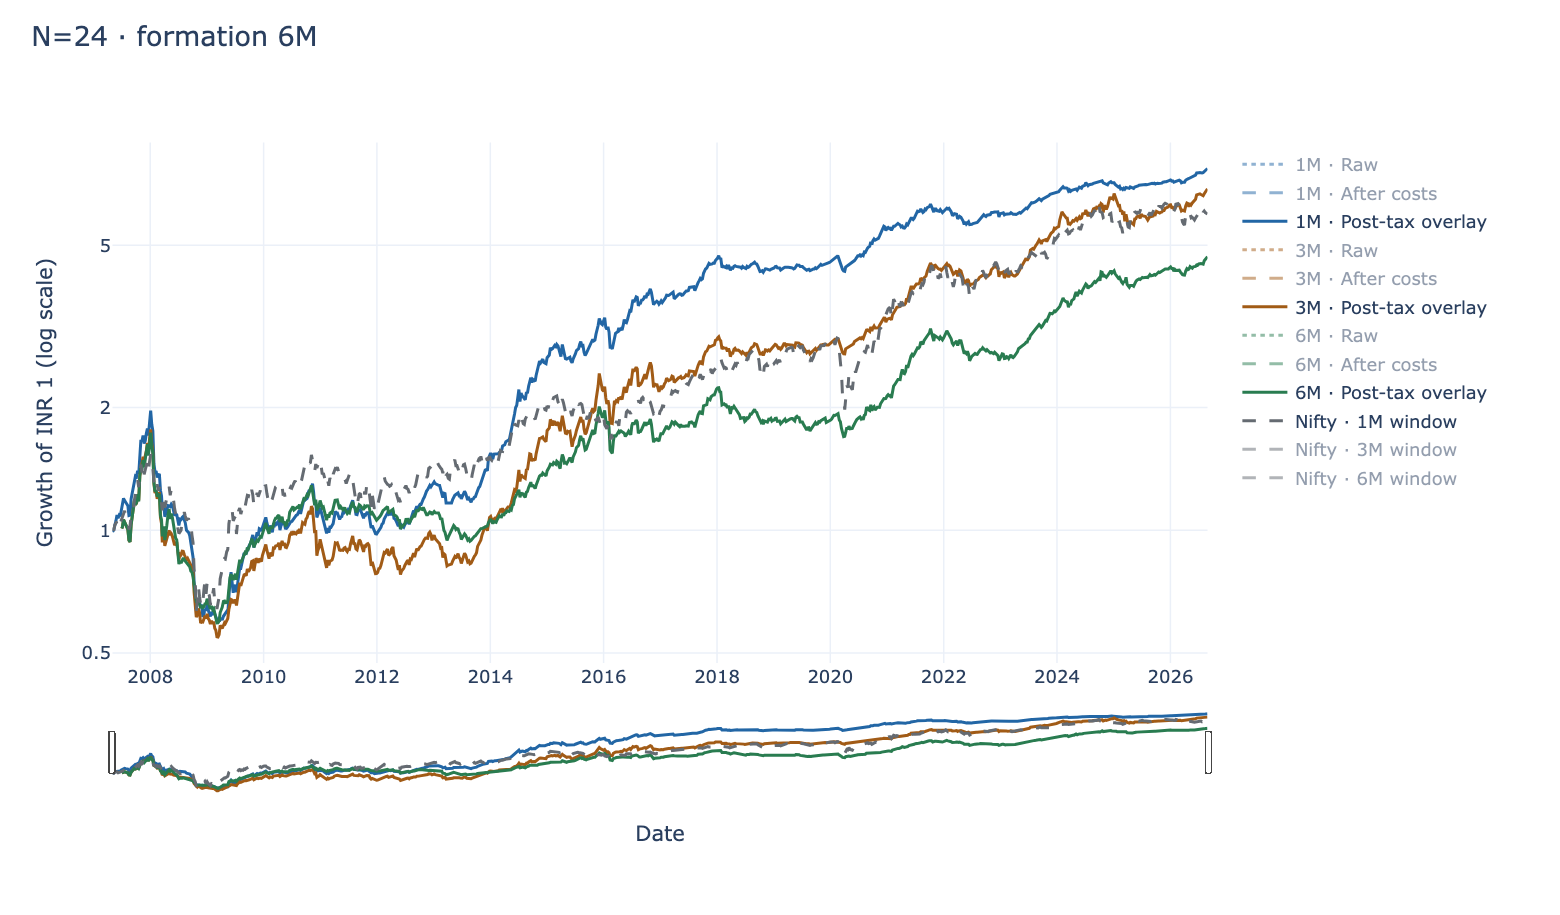

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,13.1%,0.475,-68.8%,5.8%
1M,After costs,12.5%,0.434,-69.5%,5.9%
1M,Post-tax overlay,11.2%,0.341,-70.5%,5.9%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,12.5%,0.390,-68.2%,7.2%
3M,After costs,12.1%,0.370,-68.5%,7.3%
3M,Post-tax overlay,10.6%,0.280,-70.1%,7.3%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,9.7%,0.243,-63.9%,6.3%
6M,After costs,9.5%,0.229,-64.2%,6.3%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,11.6%,88.8%,1563
1M,After costs,11.7%,89.8%,1580
3M,Raw,13.0%,91.3%,1680
3M,After costs,13.1%,91.5%,1687
6M,Raw,12.5%,92.2%,1848
6M,After costs,12.6%,92.5%,1861
1M,Post-tax overlay,12.1%,91.1%,1587
3M,Post-tax overlay,13.5%,92.8%,1731
6M,Post-tax overlay,13.1%,93.8%,1918
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

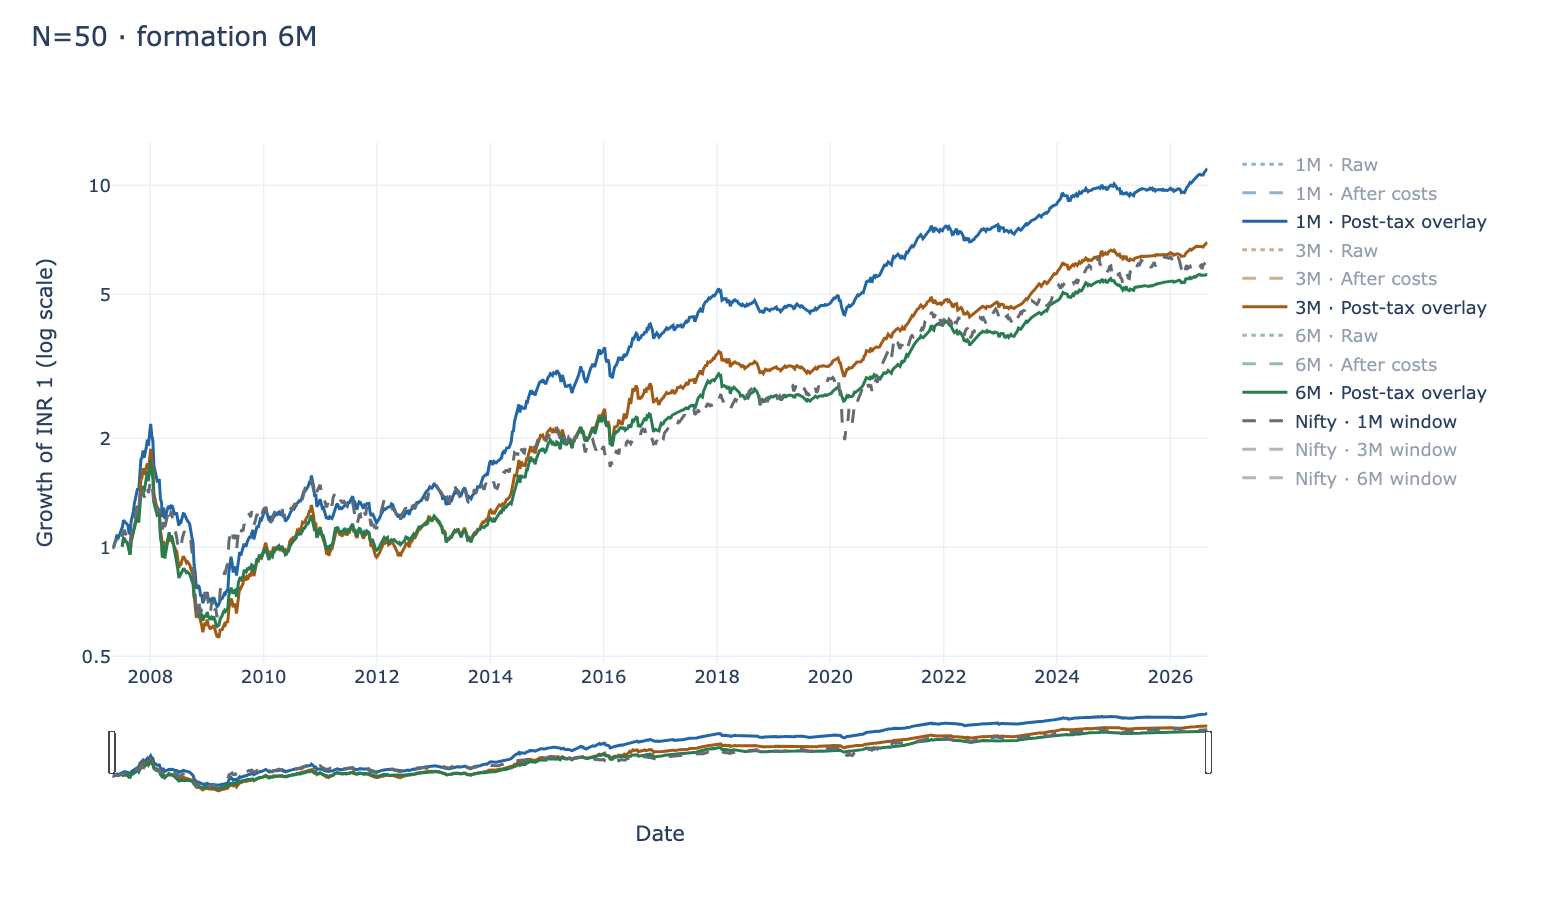

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,15.7%,0.628,-68.0%,5.7%
1M,After costs,15.0%,0.583,-68.5%,5.8%
1M,Post-tax overlay,13.3%,0.468,-69.5%,6.0%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,12.4%,0.408,-68.9%,7.0%
3M,After costs,12.0%,0.386,-69.2%,7.0%
3M,Post-tax overlay,10.7%,0.297,-70.4%,7.0%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.8%,0.327,-63.5%,5.9%
6M,After costs,10.6%,0.311,-63.8%,6.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,11.4%,87.4%,1564
1M,After costs,11.6%,87.9%,1576
3M,Raw,12.1%,89.4%,1602
3M,After costs,12.2%,89.8%,1644
6M,Raw,11.3%,89.9%,1633
6M,After costs,11.4%,90.2%,1639
1M,Post-tax overlay,11.8%,89.4%,1581
3M,Post-tax overlay,12.5%,91.5%,1647
6M,Post-tax overlay,11.8%,91.5%,1653
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-09,2014-06-16,1587,2351,-70.5%
3M,2008-01-07,2009-03-09,2015-01-19,1731,2568,-70.1%
6M,2008-01-07,2009-03-09,2015-10-21,1918,2843,-66.8%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,20.78,51.2%,67.5%
1M,24,37.82,35.8%,67.5%
1M,50,78.53,25.3%,71.1%
3M,12,15.61,24.2%,34.2%
3M,24,33.01,30.7%,40.7%
3M,50,76.14,27.5%,50.4%
6M,12,16.38,45.1%,27.4%
6M,24,31.97,38.5%,26.1%
6M,50,66.90,39.0%,29.3%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,16.7%,"2,118,845.85",0
1M,24,19.8%,"3,280,358.55",0
1M,50,21.1%,"5,115,634.22",0
3M,12,48.6%,"8,134,499.65",0
3M,24,42.2%,"2,074,354.69",0
3M,50,36.6%,"1,857,750.54",0
6M,12,41.6%,"1,140,739.99",0
6M,24,45.7%,"900,320.66",0
6M,50,44.0%,"1,044,660.69",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

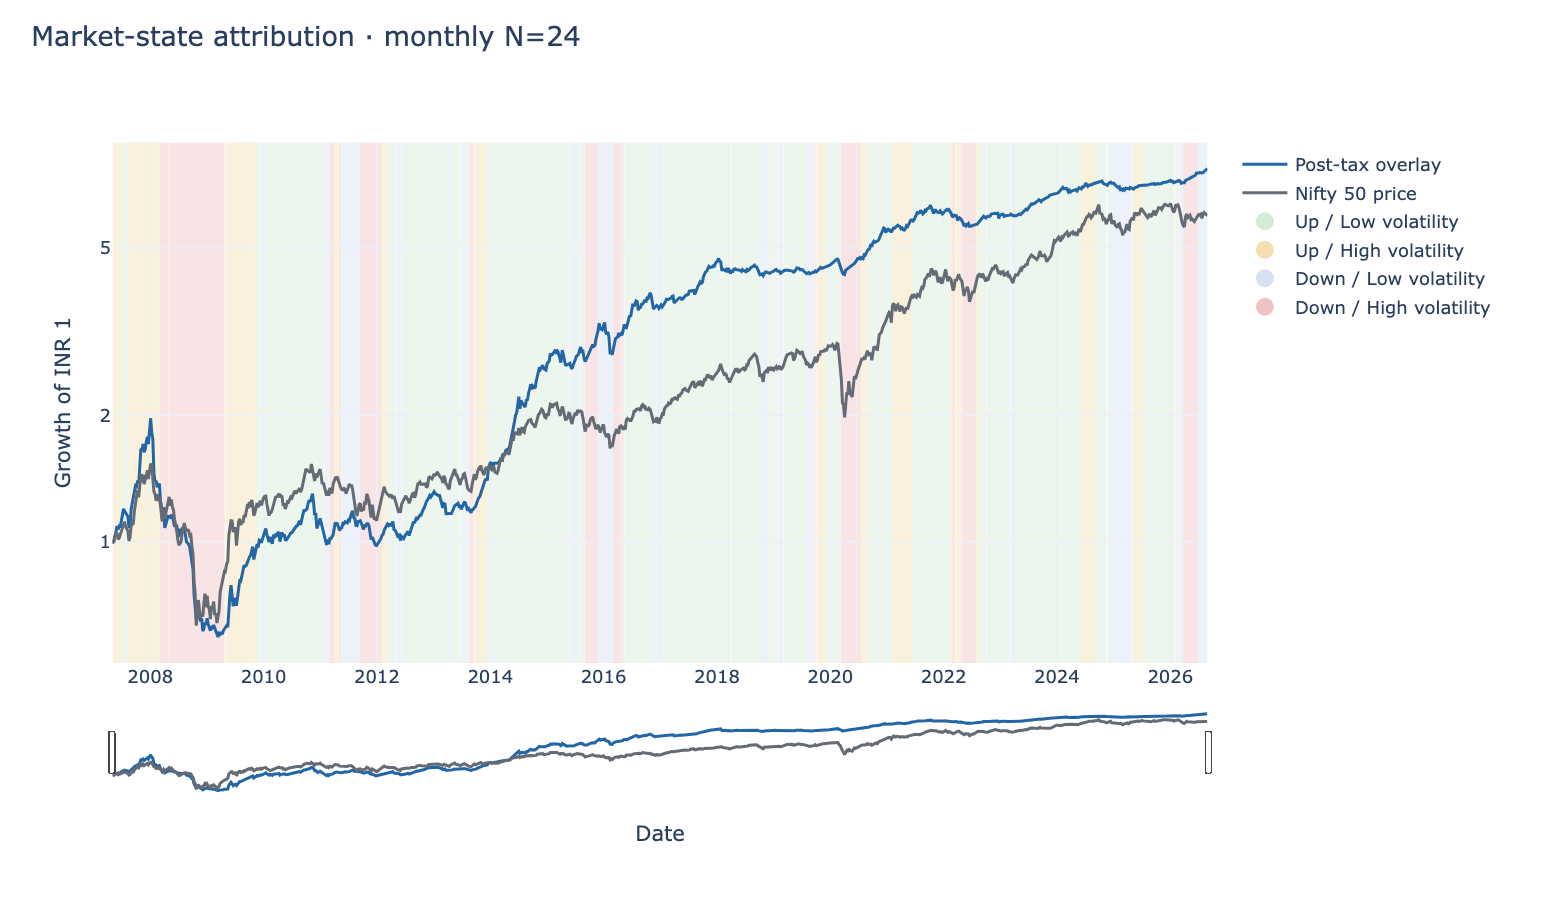

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.06%,0.94%,54.41%
Down / Low volatility,609,-0.01%,0.73%,52.55%
Up / High volatility,720,0.17%,1.33%,61.39%
Up / Low volatility,2694,0.05%,0.69%,59.50%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,4820
1M,24,2007-05-03,2026-08-03,232,8775
1M,50,2007-05-03,2026-08-03,232,18219
3M,12,2007-07-02,2026-07-01,77,1202
3M,24,2007-07-02,2026-07-01,77,2542
3M,50,2007-07-02,2026-07-01,77,5863
6M,12,2007-07-02,2026-07-01,39,639
6M,24,2007-07-02,2026-07-01,39,1247
6M,50,2007-07-02,2026-07-01,39,2609


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 6M — Winner Drift](03_raw_momentum_6m_winner_drift.ipynb). The comparison holds formation, maintenance, frequency and N fixed.